# Unified Model Training

One `SingleShotDenoiserA` trained simultaneously on all 13 perturbation conditions.

Key differences from the previous per-condition setup:
- **Full proteome** (~16k training proteins after length filter, vs 800 before)
- **On-the-fly simulation** — fresh VibeTags sample each epoch (unlimited augmentation)
- **Random condition sampling** — every batch mixes all 13 noise levels
- **Mild input smoothing** (eps=0.02) applied consistently at train and eval
- Evaluated separately on each condition against the fixed `eval_unified_seed42.h5`

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import torch
import torch.nn.functional as F
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm import tqdm

from data.vibeseq.simulation.naive import load_confusion_matrix
from models.properties import AA_ORDER
from models.single_shot import SingleShotDenoiserA
from models.unified_dataset import (
    PERTURBATION_CONDITIONS,
    make_train_loader, make_eval_loader,
)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

SEED      = 42
EPOCHS    = 30
BATCH     = 32
LR        = 1e-3
MAX_LEN   = 1000
MILD_EPS  = 0.02
DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'

SRC_H5    = Path('../data/synthetic/naive_full_seed42.h5')
EVAL_H5   = Path('../data/synthetic/eval_unified_seed42.h5')
CKPT_PATH = Path('../models/checkpoints/unified_single_shot.pt')
CM_PATH   = Path('../assets/rf_cm.npy')

aa_to_idx = {aa: i for i, aa in enumerate(AA_ORDER)}
classes, cm_frac = load_confusion_matrix(CM_PATH)

print(f'Device: {DEVICE}')

Device: cpu


In [2]:
# Generate eval dataset if it doesn't already exist (takes ~5 min)
if not EVAL_H5.exists():
    print('Generating eval dataset...')
    import subprocess, sys
    result = subprocess.run(
        [sys.executable, str(Path('../scripts/generate_eval_dataset.py'))],
        capture_output=True, text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print('STDERR:', result.stderr)
        raise RuntimeError('Eval generation failed')
else:
    print(f'Eval dataset exists: {EVAL_H5}')

Generating eval dataset...
Total proteins (len ≤ 1000): 18,143
Val proteins:                      3,629
Output → /Users/jonathanzhao/Desktop/Whole Sequence Model/whole_sequence_model/notebooks/../data/synthetic/eval_unified_seed42.h5
Done.



In [3]:
# Train / val split — identical seed to eval generation script
with h5py.File(SRC_H5, 'r') as f:
    all_pids  = list(f.keys())
    sequences = {pid: f[pid]['sequence'][()].decode() for pid in all_pids}

# Filter long proteins
sequences = {pid: seq for pid, seq in sequences.items() if len(seq) <= MAX_LEN}
all_pids  = list(sequences.keys())

rng_split  = np.random.default_rng(SEED)
pids       = rng_split.permutation(all_pids).tolist()
split      = int(len(pids) * 0.8)
train_pids = pids[:split]
val_pids   = pids[split:]

train_sequences = [(pid, sequences[pid]) for pid in train_pids]

print(f'Proteins (len ≤ {MAX_LEN}): {len(all_pids):,}')
print(f'Train: {len(train_pids):,}   Val: {len(val_pids):,}')

Proteins (len ≤ 1000): 18,143
Train: 14,514   Val: 3,629


In [4]:
train_loader = make_train_loader(
    train_sequences, classes, cm_frac, aa_to_idx,
    batch_size=BATCH, num_workers=4, mild_eps=MILD_EPS, max_len=MAX_LEN,
)

# One eval loader per condition — all share the same val_pids
eval_loaders = {
    cond: make_eval_loader(EVAL_H5, cond, val_pids, aa_to_idx,
                           batch_size=64, mild_eps=MILD_EPS)
    for cond in PERTURBATION_CONDITIONS
}

print(f'Train batches/epoch: {len(train_loader):,}')
print(f'Eval conditions:     {len(eval_loaders)}')

Train batches/epoch: 454
Eval conditions:     13


In [5]:
model = SingleShotDenoiserA(hidden_dim=128, n_layers=2, dropout=0.1).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {n_params:,}')

# fit_stats on a sample of training data (prop_mean/std for z-score normalisation)
from models.single_shot import collate_fn
from torch.utils.data import DataLoader
from models.unified_dataset import UnifiedTrainDataset, collate_fn as ucollate

# Use existing train loader for fit_stats
model.fit_stats(train_loader, device=DEVICE)
print('fit_stats done')

Parameters: 25,236
fit_stats done


In [6]:
def run_epoch(model, loader, optimizer=None, device='cpu'):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss = total_correct = total_tokens = 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for probs, labels in loader:
            probs, labels = probs.to(device), labels.to(device)
            logits = model(probs)
            loss = F.cross_entropy(
                logits.reshape(-1, 20), labels.reshape(-1), ignore_index=-1
            )
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            mask = labels != -1
            total_correct += (logits.argmax(-1)[mask] == labels[mask]).sum().item()
            total_tokens  += mask.sum().item()
            total_loss    += loss.item() * mask.sum().item()

    return total_loss / total_tokens, total_correct / total_tokens


@torch.no_grad()
def eval_all_conditions(model, eval_loaders, device='cpu'):
    """Returns dict condition → accuracy."""
    model.eval()
    results = {}
    for cond, loader in eval_loaders.items():
        _, acc = run_epoch(model, loader, optimizer=None, device=device)
        results[cond] = acc
    return results

In [7]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = []
best_avg_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, optimizer, DEVICE)
    scheduler.step()

    # Evaluate on all conditions every 5 epochs (and final)
    if epoch % 5 == 0 or epoch == EPOCHS:
        cond_accs = eval_all_conditions(model, eval_loaders, DEVICE)
        avg_acc   = np.mean(list(cond_accs.values()))
        history.append({'epoch': epoch, 'tr_loss': tr_loss, 'tr_acc': tr_acc,
                        'avg_acc': avg_acc, **cond_accs})

        if avg_acc > best_avg_acc:
            best_avg_acc = avg_acc
            torch.save(model.state_dict(), CKPT_PATH)

        print(f'Epoch {epoch:3d}  '
              f'tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.3%}  '
              f'avg_val={avg_acc:.3%}  '
              f'gamma1={cond_accs["perturb_gamma1"]:.3%}  '
              f'scr20={cond_accs["scramble_20pct"]:.3%}  '
              f'lc20={cond_accs["lowconf_20pct"]:.3%}')
    else:
        history.append({'epoch': epoch, 'tr_loss': tr_loss, 'tr_acc': tr_acc})
        print(f'Epoch {epoch:3d}  tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.3%}')

print(f'\nBest avg val acc: {best_avg_acc:.3%}  →  {CKPT_PATH}')

Epoch   1  tr_loss=0.8486  tr_acc=79.515%
Epoch   2  tr_loss=0.6003  tr_acc=85.199%
Epoch   3  tr_loss=0.5861  tr_acc=85.020%
Epoch   4  tr_loss=0.5757  tr_acc=84.855%
Epoch   5  tr_loss=0.5538  tr_acc=85.179%  avg_val=85.124%  gamma1=96.588%  scr20=68.297%  lc20=68.381%
Epoch   6  tr_loss=0.5482  tr_acc=85.178%
Epoch   7  tr_loss=0.5432  tr_acc=85.181%
Epoch   8  tr_loss=0.5360  tr_acc=85.321%
Epoch   9  tr_loss=0.5419  tr_acc=85.093%
Epoch  10  tr_loss=0.5328  tr_acc=85.273%  avg_val=85.228%  gamma1=96.897%  scr20=68.803%  lc20=68.382%
Epoch  11  tr_loss=0.5298  tr_acc=85.319%
Epoch  12  tr_loss=0.5343  tr_acc=85.139%
Epoch  13  tr_loss=0.5271  tr_acc=85.343%
Epoch  14  tr_loss=0.5331  tr_acc=85.084%
Epoch  15  tr_loss=0.5285  tr_acc=85.223%  avg_val=85.279%  gamma1=97.015%  scr20=69.050%  lc20=68.382%
Epoch  16  tr_loss=0.5313  tr_acc=85.125%
Epoch  17  tr_loss=0.5210  tr_acc=85.380%
Epoch  18  tr_loss=0.5235  tr_acc=85.300%
Epoch  19  tr_loss=0.5234  tr_acc=85.283%
Epoch  20  tr_lo

In [8]:
# Load best checkpoint and run final eval
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
final_accs = eval_all_conditions(model, eval_loaders, DEVICE)

LABELS = {
    'ground_truth':    'Ground truth',
    'perturb_gamma50': 'Dirichlet γ=50',
    'perturb_gamma10': 'Dirichlet γ=10',
    'perturb_gamma3':  'Dirichlet γ=3',
    'perturb_gamma1':  'Dirichlet γ=1',
    'scramble_1pct':   'Scramble 1%',
    'scramble_5pct':   'Scramble 5%',
    'scramble_10pct':  'Scramble 10%',
    'scramble_20pct':  'Scramble 20%',
    'lowconf_1pct':    'Low-conf 1%',
    'lowconf_5pct':    'Low-conf 5%',
    'lowconf_10pct':   'Low-conf 10%',
    'lowconf_20pct':   'Low-conf 20%',
}

# Baseline: argmax accuracy on eval data
@torch.no_grad()
def argmax_baseline(loader):
    correct = total = 0
    for probs, labels in loader:
        mask = labels != -1
        pred = probs.argmax(-1)
        correct += (pred[mask] == labels[mask]).sum().item()
        total   += mask.sum().item()
    return correct / total

records = []
for cond in PERTURBATION_CONDITIONS:
    argmax_acc = argmax_baseline(eval_loaders[cond])
    records.append({
        'condition': LABELS[cond],
        'argmax':    argmax_acc,
        'unified':   final_accs[cond],
        'delta':     final_accs[cond] - argmax_acc,
    })

df = pd.DataFrame(records)
df_display = df.copy()
df_display['argmax']  = df['argmax'].map('{:.3%}'.format)
df_display['unified'] = df['unified'].map('{:.3%}'.format)
df_display['delta']   = df['delta'].map('{:+.3%}'.format)
df_display

,condition,argmax,unified,delta
0,Ground truth,100.000%,100.000%,+0.000%
1,Dirichlet γ=50,100.000%,100.000%,+0.000%
2,Dirichlet γ=10,99.998%,99.979%,-0.019%
3,Dirichlet γ=3,99.381%,99.466%,+0.086%
4,Dirichlet γ=1,95.740%,97.094%,+1.354%
5,Scramble 1%,82.146%,82.246%,+0.100%
6,Scramble 5%,79.015%,79.492%,+0.477%
7,Scramble 10%,75.120%,76.068%,+0.947%
8,Scramble 20%,67.339%,69.225%,+1.885%
9,Low-conf 1%,82.147%,82.197%,+0.050%


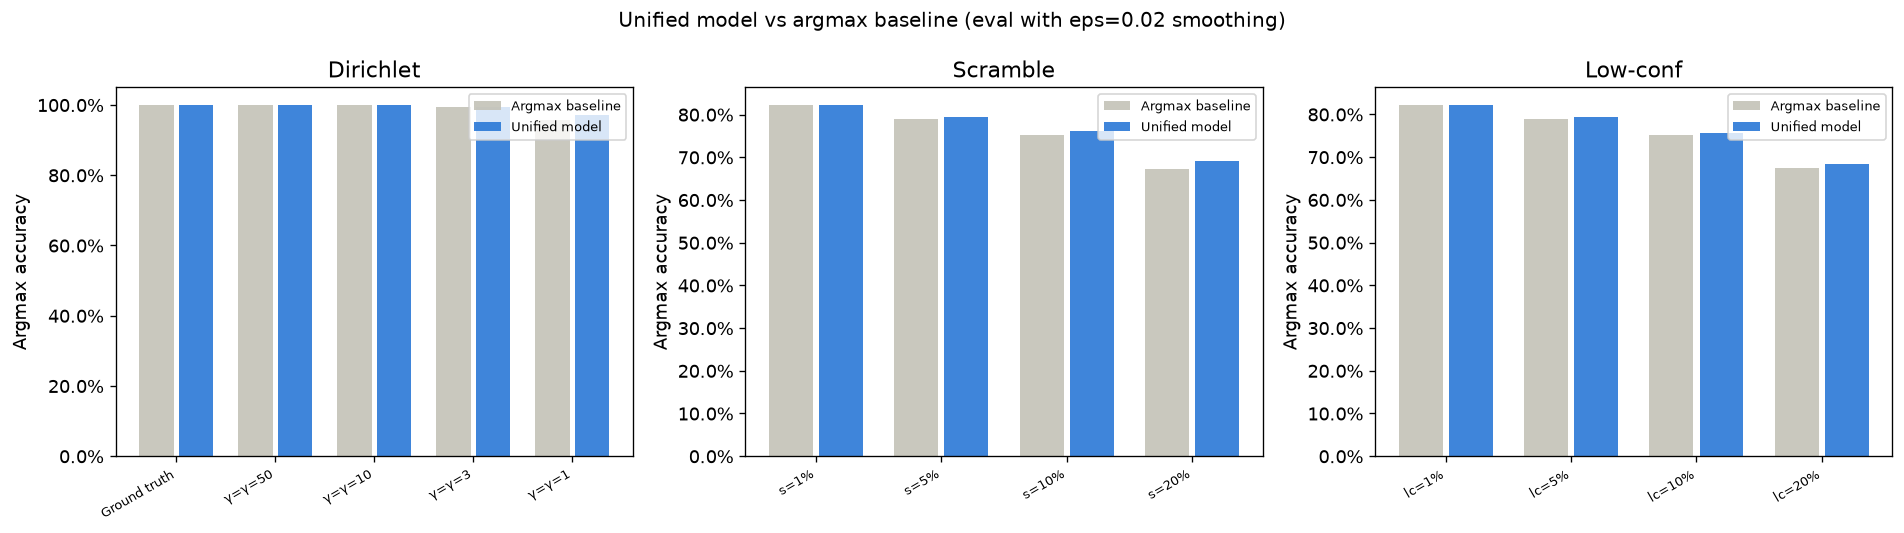

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
groups = [
    ('Dirichlet', [c for c in PERTURBATION_CONDITIONS if c.startswith('perturb') or c == 'ground_truth']),
    ('Scramble',  [c for c in PERTURBATION_CONDITIONS if c.startswith('scramble')]),
    ('Low-conf',  [c for c in PERTURBATION_CONDITIONS if c.startswith('lowconf')]),
]

for ax, (title, keys) in zip(axes, groups):
    sub_df = df.set_index('condition').loc[[LABELS[k] for k in keys]]
    x = np.arange(len(keys))
    ax.bar(x - 0.2, sub_df['argmax'],  width=0.35, label='Argmax baseline', color='#c3c2b7', alpha=0.9)
    ax.bar(x + 0.2, sub_df['unified'], width=0.35, label='Unified model',   color='#2a78d6', alpha=0.9)
    xlbls = [LABELS[k].replace('Dirichlet ', 'γ=').replace('Scramble ', 's=').replace('Low-conf ', 'lc=') for k in keys]
    ax.set_xticks(x); ax.set_xticklabels(xlbls, rotation=30, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=1))
    ax.set(title=title, ylabel='Argmax accuracy')
    ax.legend(fontsize=8)

fig.suptitle('Unified model vs argmax baseline (eval with eps=0.02 smoothing)', fontsize=12)
fig.tight_layout()
plt.show()

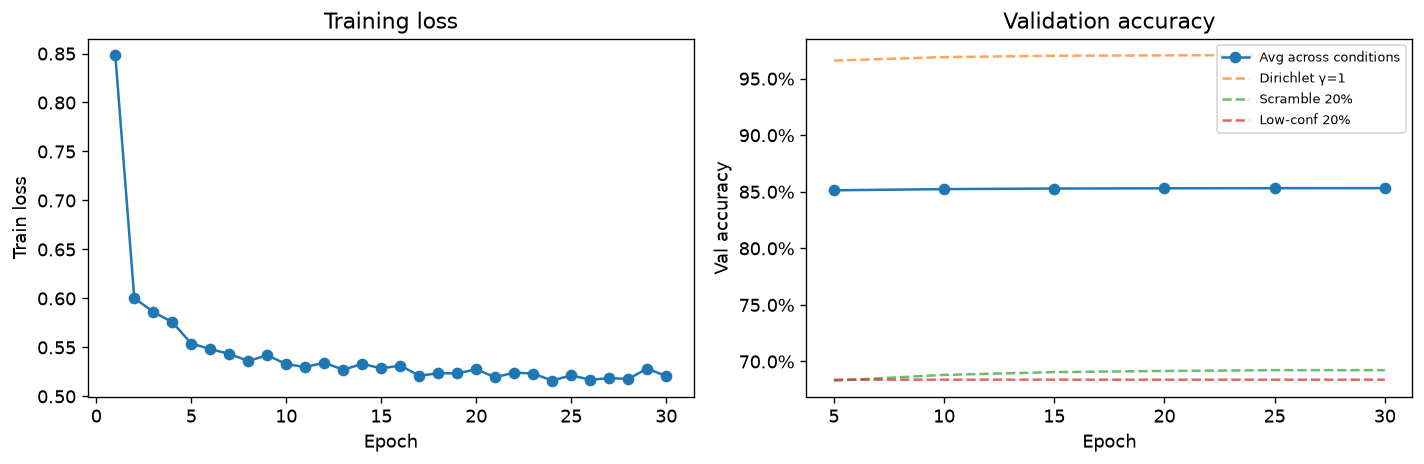

In [10]:
# Plot training curve (epochs where eval was run)
eval_hist = [h for h in history if 'avg_acc' in h]
if len(eval_hist) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = [h['epoch'] for h in eval_hist]

    axes[0].plot([h['epoch'] for h in history], [h['tr_loss'] for h in history], 'o-')
    axes[0].set(xlabel='Epoch', ylabel='Train loss', title='Training loss')

    axes[1].plot(epochs, [h['avg_acc'] for h in eval_hist], 'o-', label='Avg across conditions')
    for cond in ['perturb_gamma1', 'scramble_20pct', 'lowconf_20pct']:
        if cond in eval_hist[0]:
            axes[1].plot(epochs, [h[cond] for h in eval_hist], '--', label=LABELS[cond], alpha=0.7)
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=1))
    axes[1].set(xlabel='Epoch', ylabel='Val accuracy', title='Validation accuracy')
    axes[1].legend(fontsize=8)

    fig.tight_layout()
    plt.show()